<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_03_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent for Aerodynamic Shape Optimization

In aerospace design, we frequently minimize an objective function by tweaking design variables. For example, minimizing the **Drag Coefficient ($C_D$)** by adjusting the **Wing Sweep Angle ($\Lambda$, X-axis)** and **Wing Dihedral Angle ($\Gamma$, Y-axis)**.

Gradient descent is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function. The basic update rule to find the minimum of our drag function $f(\Lambda, \Gamma)$ is:

$$ \begin{bmatrix} \Lambda \\ \Gamma \end{bmatrix}_{n+1} = \begin{bmatrix} \Lambda \\ \Gamma \end{bmatrix}_n - \gamma \nabla f(\Lambda_n, \Gamma_n) $$

Where:
*   $\nabla f$ is the gradient vector of the drag surface.
*   $\gamma$ is the **learning rate** (step size).

### Convex vs. Non-Convex Optimization
*   **Convex Problems:** The drag surface resembles a simple bowl. There is only one global minimum. Gradient descent will find it regardless of the starting point.
*   **Non-Convex Problems:** Typical in multi-disciplinary design. The surface has multiple "valleys" (local minima). Gradient descent might get trapped in a sub-optimal valley depending on where you start your initial design guess.

The code from the textbook [1] was extensively refactored for clarity and framed within this aerospace context.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC02_1_GradientDescent.ipynb

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D

# Configure plotting aesthetics
rcParams.update({'font.size': 12})

def plot_aero_surface(X, Y, Z, title, elev=30, azim=-60):
    """
    Helper function to plot a 3D aerodynamic performance surface.
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    surf = ax.plot_surface(X, Y, Z, cmap='gray', edgecolor='none', alpha=0.70)

    # Add contour projection below
    ax.contour(X, Y, Z, zdir='z', offset=np.min(Z)-0.5, cmap='viridis', alpha=0.5)

    ax.set_title(title)
    ax.set_xlabel(r'Wing Sweep, $\Lambda$ (deg)')
    ax.set_ylabel(r'Wing Dihedral, $\Gamma$ (deg)')
    ax.set_zlabel(r'Drag Coefficient, $C_D$')
    ax.set_zlim(np.min(Z)-0.5, np.max(Z)+0.5)
    ax.view_init(elev=elev, azim=azim)

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label=r'$C_D$')
    return fig, ax

def gradient_descent_2d(grad_func, start_point, learning_rate=0.01, iterations=10):
    """
    Performs gradient descent on a 2D surface.
    """
    path = [np.array(start_point)]
    for i in range(iterations):
        current_pos = path[-1]
        gradient = grad_func(current_pos[0], current_pos[1])
        new_pos = current_pos - learning_rate * np.array(gradient)
        path.append(new_pos)
    return np.array(path)

In [54]:
# Define the design space (Wing Sweep X, Dihedral Y)
h = 0.5
x_sweep = np.arange(-6, 6 + h, h)
y_dihedral = np.arange(-6, 6 + h, h)
X, Y = np.meshgrid(x_sweep, y_dihedral)

# 1. Convex Drag Surface (A simple parabolic bowl)
# C_D = X^2 + 3Y^2 (Normalized around an optimal design point [0,0])
drag_convex = X**2 + 3 * Y**2

# Analytical gradients for the convex surface
def grad_convex(x, y):
    dcd_dx = 2 * x
    dcd_dy = 6 * y
    return [dcd_dx, dcd_dy]

# 2. Non-Convex Drag Surface (Complex aerodynamic interaction space)
# We model this using Gaussian wells representing different local minima
drag_non_convex = ( 1.5 - np.exp(-0.05 * (3 * (X + 3)**2 + (Y + 3)**2)) +
                    0.5 - np.exp(-0.1 * (3 * (X - 3)**2 + (Y - 3)**2)) )

# Analytical gradients for the non-convex surface
def grad_non_convex(x, y):
    term1 = np.exp(-0.05 * (3 * (x + 3)**2 + (y + 3)**2))
    term2 = np.exp(-0.1 * (3 * (x - 3)**2 + (y - 3)**2))

    dcd_dx = -term1 * (-0.05 * 6 * (x + 3)) - term2 * (-0.1 * 6 * (x - 3))
    dcd_dy = -term1 * (-0.05 * 2 * (y + 3)) - term2 * (-0.1 * 2 * (y - 3))
    return [dcd_dx, dcd_dy]

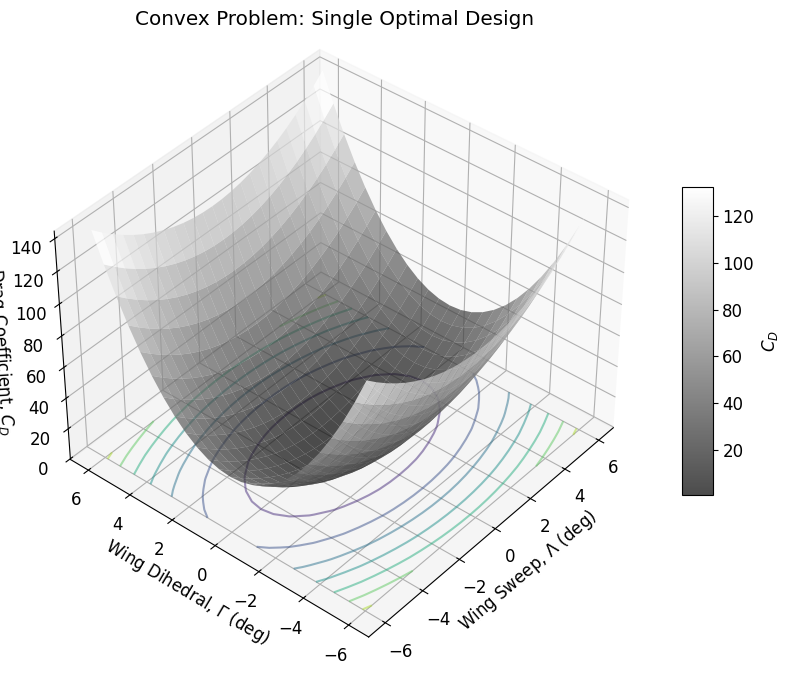

In [55]:
# Visualize the Convex Design Space
fig, ax = plot_aero_surface(X, Y, drag_convex, "Convex Problem: Single Optimal Design", elev=40, azim=-140)
plt.show()

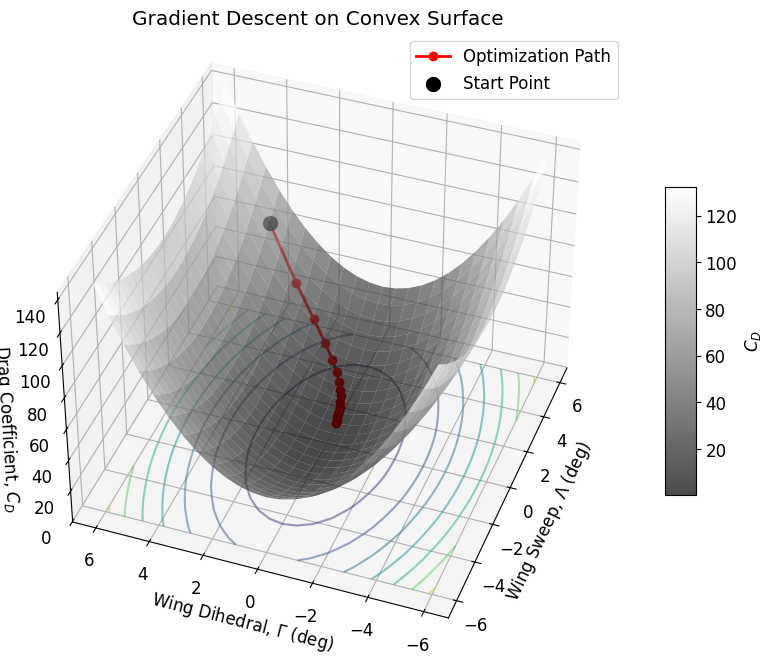

In [56]:
# Let's perform gradient descent on the CONVEX surface
start_guess = [5.0, 4.0]  # Initial sub-optimal design
learning_rate = 0.05
iterations = 15

# Run the optimization
path = gradient_descent_2d(grad_convex, start_guess, learning_rate, iterations)
x_path, y_path = path[:, 0], path[:, 1]
z_path = [x**2 + 3*y**2 for x, y in zip(x_path, y_path)]

# Plot the optimization trajectory
fig, ax = plot_aero_surface(X, Y, drag_convex, "Gradient Descent on Convex Surface", elev=40, azim=-160)
ax.plot(x_path, y_path, z_path, color='r', marker='o', markersize=6, linewidth=2, label='Optimization Path')
ax.scatter(start_guess[0], start_guess[1], start_guess[0]**2 + 3*start_guess[1]**2, color='k', s=100, label='Start Point')
ax.legend()
plt.show()

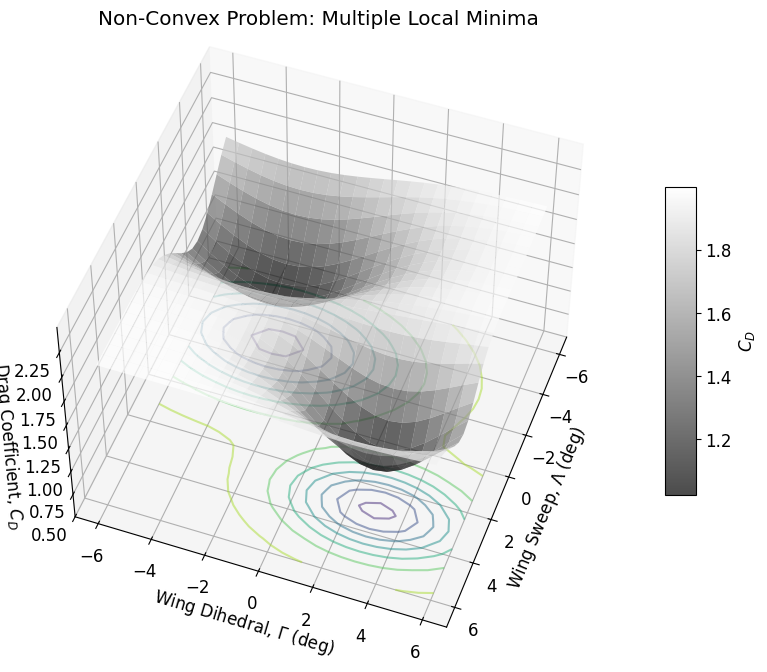

In [57]:
# Visualize the Non-Convex Design Space
# Notice life is much harder! Depending on where you start, you might slide into the "wrong" valley.
fig, ax = plot_aero_surface(X, Y, drag_non_convex, "Non-Convex Problem: Multiple Local Minima", elev=50, azim=20)
plt.show()

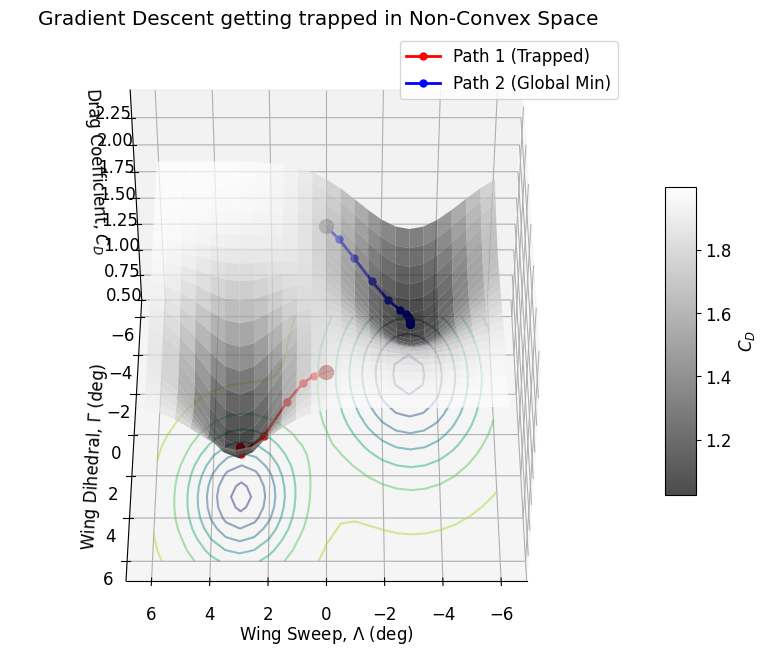

In [58]:
# Let's perform gradient descent on the NON-CONVEX surface starting from two different initial guesses
start_guess_1 = [0.0, 4.0]   # Leads to local minimum
start_guess_2 = [0.0, -4.0]  # Leads to global minimum

lr = 2.0  # Note: The non-convex gradients here are very small (exponentials), so we need a larger step size.
iters = 25

path1 = gradient_descent_2d(grad_non_convex, start_guess_1, lr, iters)
path2 = gradient_descent_2d(grad_non_convex, start_guess_2, lr, iters)

# We need a helper to evaluate the Z coordinate for plotting the path
def eval_non_convex(x, y):
    return 1.5 - np.exp(-0.05 * (3 * (x + 3)**2 + (y + 3)**2)) + 0.5 - np.exp(-0.1 * (3 * (x - 3)**2 + (y - 3)**2))

z_path1 = [eval_non_convex(x, y) for x, y in zip(path1[:,0], path1[:,1])]
z_path2 = [eval_non_convex(x, y) for x, y in zip(path2[:,0], path2[:,1])]

fig, ax = plot_aero_surface(X, Y, drag_non_convex, "Gradient Descent getting trapped in Non-Convex Space", elev=45, azim=90)

# Trajectory 1
ax.plot(path1[:,0], path1[:,1], np.array(z_path1), color='r', marker='o', markersize=5, markeredgecolor='r',linewidth=2, label='Path 1 (Trapped)')
ax.scatter(start_guess_1[0], start_guess_1[1], eval_non_convex(start_guess_1[0], start_guess_1[1]), color='darkred', s=100)

# Trajectory 2
ax.plot(path2[:,0], path2[:,1], np.array(z_path2), color='b', marker='o', markersize=5, markeredgecolor='b', linewidth=2, label='Path 2 (Global Min)')
ax.scatter(start_guess_2[0], start_guess_2[1], eval_non_convex(start_guess_2[0], start_guess_2[1]), color='gray', s=100)

ax.legend()
plt.show()

### Challenge Problem: Momentum-Based Optimization
Standard gradient descent getting trapped in local minimums (like our non-convex drag surface) is a major problem. Advanced optimizers like **Momentum** or **Adam** build up "velocity" to push through small local bumps. Your challenge: Implement a basic Gradient Descent with Momentum loop and demonstrate how it can roll past the local minimum on the non-convex surface.

In [59]:
# YOUR CODE HERE
# Implement gradient descent with momentum:
# v = beta * v - learning_rate * gradient
# pos = pos + v
# Test if it can escape the local minimum starting from [0.0, 4.0] where standard GD failed.
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
def gradient_descent_momentum(grad_func, start_point, lr=1.0, beta=0.9, iters=25):
    path = [np.array(start_point)]
    v = np.zeros(2)
    for i in range(iters):
        current_pos = path[-1]
        grad = np.array(grad_func(current_pos[0], current_pos[1]))
        v = beta * v - lr * grad
        new_pos = current_pos + v
        path.append(new_pos)
    return np.array(path)

# Starting point that trapped standard GD
start_guess = [0.0, 4.0]

# Run with momentum
path_mom = gradient_descent_momentum(grad_non_convex, start_guess, lr=1.5, beta=0.8, iters=40)

z_path_mom = [eval_non_convex(x, y) for x, y in zip(path_mom[:,0], path_mom[:,1])]

fig, ax = plot_aero_surface(X, Y, drag_non_convex, "Momentum Escaping Local Minima", elev=50, azim=20)
ax.plot(path_mom[:,0], path_mom[:,1], z_path_mom, color='cyan', marker='o', markersize=4, linewidth=2, label='Momentum Path (Escapes to Global Min)')
ax.scatter(start_guess[0], start_guess[1], eval_non_convex(start_guess[0], start_guess[1]), color='yellow', s=100)
ax.legend()
plt.show()
```
</details>